# Club Football Match Data: Analysis and Modelling

# 1. Introduction

In this notebook, I will analyse the **Matches.csv** and **EloRatings.csv** datasets, which contain club football match data covering the period from 2000 to 2025. I will focus primarily on the **English Premier League**, using the match results and associated statistics to investigate patterns in team and match performance.

The first part of the notebook will be exploratory, with the aim of understanding the data and investigating questions such as how attacking performance, shot statistics and home advantage relate to match outcomes and league performance. I will use Python to clean, summarise and visualise the data, as well as applying statistical methods to quantify relationships found during the exploratory analysis.

The latter part of the notebook will move towards **predictive modelling**, where I will investigate whether information available before a match can be used to predict its outcome. Several classification models will be considered and their performance compared.

This notebook is also an opportunity to develop my understanding of data analysis in Python, particularly in relation to data preparation, visualisation, statistical analysis and introductory machine learning.

In [1]:
# libraries
# Numerical and data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Utility functions
import difflib

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import chisquare

The analysis uses two datasets. **Matches.csv** contains match-level information, including the teams involved, match result and match statistics. **EloRatings.csv** contains Elo ratings that can be used to compare the relative strength of teams over time.

In [2]:
# load datasets
MatchData= pd.read_csv('/kaggle/input/datasets/adamgbor/club-football-match-data-2000-2025/Matches.csv')
EloRatings = pd.read_csv('/kaggle/input/datasets/adamgbor/club-football-match-data-2000-2025/EloRatings.csv')

/tmp/ipykernel_16/2048531205.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  MatchData= pd.read_csv('/kaggle/input/datasets/adamgbor/club-football-match-data-2000-2025/Matches.csv')


# 2. Data Preparation and Initial Exploration

Before analysing the data, it needs to be filtered and organised into a consistent format. I will first select the Premier League matches, convert the match dates into a suitable datetime format and create a season variable. I will then check for inconsistencies in team names, as these could cause the same club to be treated as different teams when comparing performance across seasons.

## 2.1 Selecting the Premier League

The analysis will initially focus on **Matches.csv**, as this dataset contains the match-level information required for the exploratory analysis. The first step is to isolate Premier League matches from the other domestic and international competitions included in the dataset. The `Division` column identifies the competition in which each match was played. The code below selects matches where `Division == 'E0'`, corresponding to the English Premier League.

In [3]:
PremData = MatchData[MatchData['Division'] == 'E0'].copy() # filtering to just the premier league 'E0'

## 2.2 Dates and Seasons

The match dates are initially stored as strings, so they are converted to pandas datetime objects. This allows the matches to be sorted chronologically and makes it possible to extract information such as the year and month.

A season variable is then created. Premier League seasons begin in August and continue into the following calendar year. Therefore, matches played from August onwards are assigned to the year in which the season began, while matches played from January to July are assigned to the previous year. For example, a match played in February 2021 belongs to the **2020–21** season and is therefore assigned a value of `2020`.

In [4]:

PremData['MatchDate'] = pd.to_datetime(PremData['MatchDate'], format='%Y-%m-%d') # converting match data to datetime
PremData =  PremData.sort_values('MatchDate').reset_index(drop=True) # sort chronologically

# Denote the seasons
PremData['Season'] = (
    PremData['MatchDate'].dt.year.where(
        PremData['MatchDate'].dt.month >= 8,
        PremData['MatchDate'].dt.year - 1
    )
)

## 2.3 Team Name Standardisation

Before comparing clubs across multiple seasons, it is important to check that each club has been given a consistent name. If the same club appears under different names, pandas will treat these as separate teams when grouping or filtering the data.

I will first create a list of all unique home and away team names and use `difflib` to identify names that are sufficiently similar to potentially represent the same club.

In [5]:
# Combine all unique home and away team names
teams = sorted(
    set(PremData['HomeTeam'].unique()) |
    set(PremData['AwayTeam'].unique())
)

# Identify potentially similar team names
for team in teams:
    close = difflib.get_close_matches(
        team, teams, n=3, cutoff=0.75
    )
    close = [c for c in close if c != team]

    if close:
        print(f"{team} -> possible matches: {close}")

Nott'm Forest -> possible matches: ['Nottm Forest']
Nottm Forest -> possible matches: ["Nott'm Forest"]


The search identifies **"Nott'm Forest"** and **"Nottm Forest"** as potentially referring to the same club. These two names should therefore be standardised before continuing with the analysis.

In [6]:
# Standardise alternative team names
team_name_fixes = {
    "Nott'm Forest": "Nottm Forest"
}

for col in ['HomeTeam', 'AwayTeam']:
    PremData[col] = PremData[col].replace(team_name_fixes)

# Recreate the list of unique teams after standardisation
teams = sorted(
    set(PremData['HomeTeam'].unique()) |
    set(PremData['AwayTeam'].unique())
)

print(teams)

['Arsenal', 'Aston Villa', 'Birmingham', 'Blackburn', 'Blackpool', 'Bolton', 'Bournemouth', 'Bradford', 'Brentford', 'Brighton', 'Burnley', 'Cardiff', 'Charlton', 'Chelsea', 'Coventry', 'Crystal Palace', 'Derby', 'Everton', 'Fulham', 'Huddersfield', 'Hull', 'Ipswich', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Middlesbrough', 'Newcastle', 'Norwich', 'Nottm Forest', 'Portsmouth', 'QPR', 'Reading', 'Sheffield United', 'Southampton', 'Stoke', 'Sunderland', 'Swansea', 'Tottenham', 'Watford', 'West Brom', 'West Ham', 'Wigan', 'Wolves']


## 2.4 Data Validation

After standardising the team names, I will check the number of unique clubs represented in the dataset. This provides a simple validation that duplicate team names have not remained after the standardisation step.

In [7]:
print('Number of unique Premier League teams =', len(teams))

Number of unique Premier League teams = 46


The processed dataset contains **46 unique clubs** across the seasons represented. Together with the previous check showing that the two Nottingham Forest names have been consolidated, this provides a basic validation of the team-name standardisation.

In [8]:
print("Number of matches:", len(PremData))
print("Date range:", PremData['MatchDate'].min(), "to", PremData['MatchDate'].max())
print("Number of seasons:", PremData['Season'].nunique())
print("Missing values:\n", PremData.isna().sum())

Number of matches: 9410
Date range: 2000-08-19 00:00:00 to 2025-05-25 00:00:00
Number of seasons: 25
Missing values:
 Division          0
MatchDate         0
MatchTime      7130
HomeTeam          0
AwayTeam          0
HomeElo           1
AwayElo           1
Form3Home         0
Form5Home         0
Form3Away         0
Form5Away         0
FTHome            0
FTAway            0
FTResult          0
HTHome            0
HTAway            0
HTResult          0
HomeShots         0
AwayShots         0
HomeTarget        0
AwayTarget        0
HomeFouls         0
AwayFouls         0
HomeCorners       0
AwayCorners       0
HomeYellow        0
AwayYellow        0
HomeRed           0
AwayRed           0
OddHome          83
OddDraw          83
OddAway          83
MaxHome        1810
MaxDraw        1810
MaxAway        1810
Over25         1810
Under25        1810
MaxOver25      1810
MaxUnder25     1810
HandiSize      1160
HandiHome      1151
HandiAway      1160
C_LTH             0
C_LTA             0
C_

The validation shows that the filtered dataset contains **9,410 matches across 25 seasons**, covering the period from August 2000 to May 2025. This is consistent with the intended 2000–2025 study period.

There are no missing values in the core match information, including the teams, final scores, results and shot statistics. However, several other variables contain missing values. `MatchTime` has a large number of missing entries, while some betting and handicap variables also have missing observations. Since these variables are not required for the initial exploratory analysis, they will not be imputed at this stage.

There is also one missing value for each of `HomeElo` and `AwayElo`. These variables will be used later in the analysis, so their missing observations will need to be considered when the Elo-based analysis is performed.

# 3. Exploring Arsenal's Performance

Having prepared the Premier League dataset, I will now focus on an individual club to explore how match-level statistics can be used to understand performance over multiple seasons. I will use **Arsenal** as a case study.

The analysis will begin by looking at how Arsenal's points accumulate throughout a season. I will then compare final points totals with measures such as goals, goal difference and shots, before investigating whether shot volume and shot dominance are associated with match outcomes.

This provides an opportunity to explore the data at both the **season level** and the **individual match level**.

## 3.1 Arsenal Match Data

To begin the case study, I will isolate all Premier League matches involving Arsenal, whether Arsenal played at home or away. This creates a separate dataset for the club-level analysis while leaving the original Premier League dataset unchanged.

In [9]:
ArsenalData = PremData[
    (PremData['HomeTeam'] == 'Arsenal') |
    (PremData['AwayTeam'] == 'Arsenal')
].copy()

ArsenalData = ArsenalData.sort_values('MatchDate').reset_index(drop=True)

print("Number of Arsenal matches:", len(ArsenalData))
print("Number of seasons:", ArsenalData['Season'].nunique())

Number of Arsenal matches: 940
Number of seasons: 25


Arsenal's matches can be identified by selecting games in which Arsenal appears as either the home or away team. This creates a separate dataset that can be used to investigate Arsenal's performance without altering the original Premier League dataset.

## 3.2 Points Progression

A team's league performance is determined by the points it accumulates: a win is worth 3 points, a draw 1 point and a loss 0 points.

I will calculate the points Arsenal earned in each match and then calculate its cumulative points total throughout each season. Plotting this progression allows the development of Arsenal's performance to be compared between seasons, rather than looking only at the final points tally.

In [10]:
# Identify Arsenal's result in each match
is_home_win = (
    (ArsenalData["HomeTeam"] == "Arsenal") &
    (ArsenalData["FTResult"] == "H")
)

is_away_win = (
    (ArsenalData["AwayTeam"] == "Arsenal") &
    (ArsenalData["FTResult"] == "A")
)

is_draw = ArsenalData["FTResult"] == "D"

# Assign points earned by Arsenal
conditions = [is_home_win | is_away_win, is_draw]
choices = [3, 1]

ArsenalData["MatchPoints"] = np.select(
    conditions,
    choices,
    default=0
)

# Number matches within each season
ArsenalData["MatchNumber"] = (
    ArsenalData.groupby("Season").cumcount() + 1
)

# Cumulative points within each season
ArsenalData["CumulativePoints"] = (
    ArsenalData.groupby("Season")["MatchPoints"].cumsum()
)

The cumulative points can now be plotted against the number of matches played. I will initially compare three seasons to illustrate how different points trajectories can develop over the course of a season.

In [11]:
ArsenalData.head()

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB,Season,MatchPoints,MatchNumber,CumulativePoints
0,E0,2000-08-19,NaN,Sunderland,Arsenal,1712.13,1871.71,0.0,0.0,0.0,...,0.0127,0.0160,0.0274,0.0100,0.9117,0.0223,2000,0,1,0
1,E0,2000-08-21,NaN,Arsenal,Liverpool,1871.71,1770.15,0.0,0.0,9.0,...,0.0221,0.0789,0.0099,0.7480,0.0714,0.0697,2000,3,2,3
2,E0,2000-08-26,NaN,Arsenal,Charlton,1871.71,1608.77,5.0,8.0,5.0,...,0.0865,0.1361,0.0099,0.6893,0.0484,0.0299,2000,3,3,6
3,E0,2000-09-06,NaN,Chelsea,Arsenal,1792.67,1873.17,4.0,7.0,6.0,...,0.0422,0.3084,0.0100,0.2777,0.2174,0.1443,2000,1,4,7
4,E0,2000-09-09,NaN,Bradford,Arsenal,1596.85,1873.17,4.0,5.0,7.0,...,0.0307,0.4085,0.0099,0.4303,0.0370,0.0836,2000,1,5,8


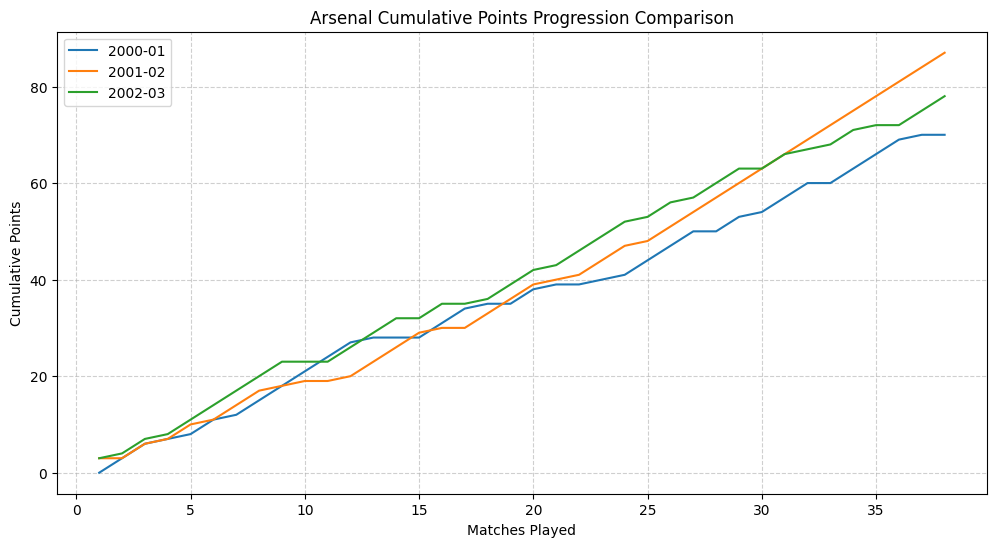

In [12]:
plt.figure(figsize=(12, 6))

# consider the 2000, 2001 and 2002 seasons
seasons_to_plot = [2000, 2001, 2002]

for season in seasons_to_plot:
    season_df = ArsenalData[ArsenalData["Season"] == season]
    plt.plot(
        season_df["MatchNumber"],
        season_df["CumulativePoints"],
        label=f"{season}-{str(season + 1)[-2:]}",
    )

plt.title("Arsenal Cumulative Points Progression Comparison")
plt.xlabel("Matches Played")
plt.ylabel("Cumulative Points")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## 3.3 Final Points by Season

The cumulative points plot shows how Arsenal's performance develops throughout individual seasons. I can also summarise each season using the final points tally, allowing Arsenal's performance to be compared across the entire 25-season period.

Rather than assuming that every season contains exactly 38 Arsenal matches, the final cumulative value for each season is obtained directly from the data using the last recorded match.

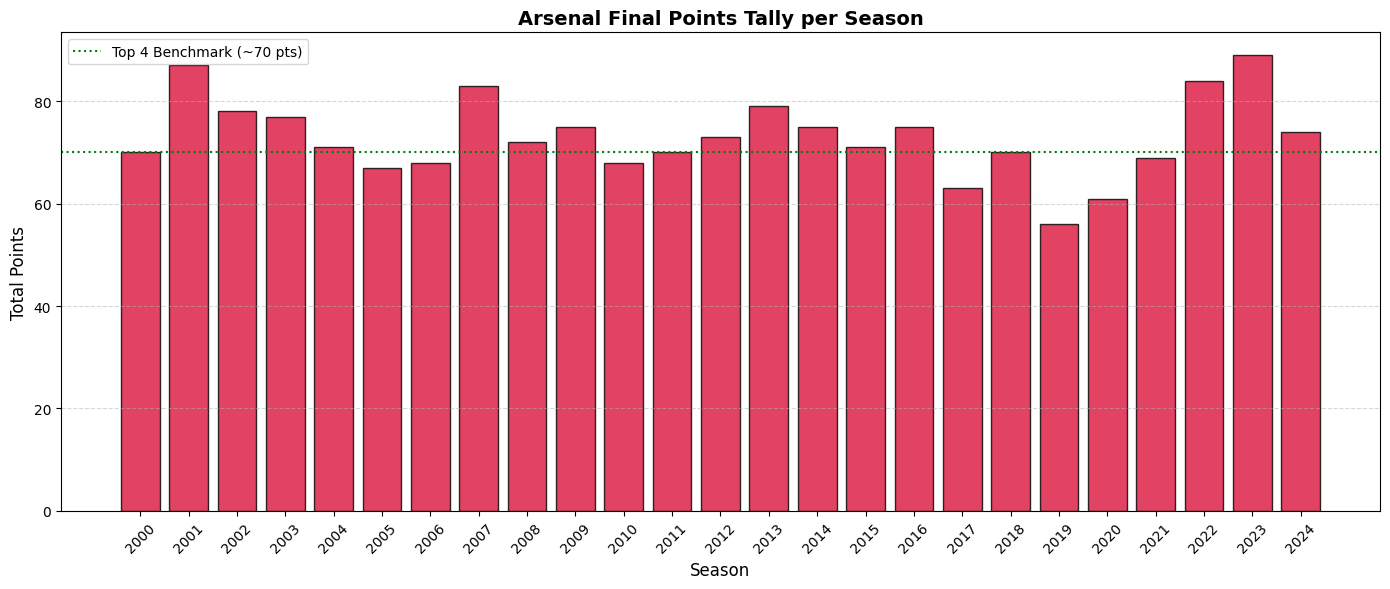

In [13]:
# season summary (season and final tally)
season_summary = (
    ArsenalData.groupby('Season')['CumulativePoints'].last().reset_index()
)

# extract data
seasons = season_summary["Season"]
final_tallies = season_summary["CumulativePoints"]

# plot
plt.figure(figsize=(14, 6))

plt.bar(seasons, final_tallies, color="crimson", edgecolor="black", alpha=0.8)

plt.title("Arsenal Final Points Tally per Season", fontsize=14, fontweight="bold")
plt.xlabel("Season", fontsize=12)
plt.ylabel("Total Points", fontsize=12)
plt.xticks(seasons, rotation=45)  # Rotates the years so they don't overlap
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Approximately required for champions league football
plt.axhline(y=70, color="green", linestyle=":", label="Top 4 Benchmark (~70 pts)")
plt.legend()

plt.tight_layout()  # Prevents labels from getting cut off at the bottom
plt.show()

The horizontal line at 70 points is included as an approximate reference for a strong league finish. It should not be interpreted as a fixed qualification threshold, since the number of points required for a particular league position varies between seasons, but this is generally good enough for champions league qualification.

## 3.4 Performance Metrics and Final Points

The variation in Arsenal's final points totals raises the question of which aspects of match performance are associated with stronger seasons.

I will investigate four measures:

- **Goals scored** — total goals Arsenal scored during the season.
- **Goal difference** — goals scored minus goals conceded.
- **Shots** — total shots taken by Arsenal.
- **Shot difference** — Arsenal's shots minus the opposition's shots.

These measures capture different aspects of performance. Goals and goal difference directly reflect scoring outcomes, while shots and shot difference provide measures of attacking activity and territorial dominance that occur before considering the final score.

I will compare each of these measures with Arsenal's final points tally to look for potential relationships.

In [14]:
# goals for/against and difference
ArsenalData["goals_for"] = np.where(
    ArsenalData["HomeTeam"] == "Arsenal",
    ArsenalData["FTHome"],
    ArsenalData["FTAway"]
)

ArsenalData["goals_against"] = np.where(
    ArsenalData["HomeTeam"] == "Arsenal",
    ArsenalData["FTAway"],
    ArsenalData["FTHome"]
)

ArsenalData["goal_difference"] = (
    ArsenalData["goals_for"] - ArsenalData["goals_against"]
)

# shots for/against and difference
ArsenalData["shots_for"] = np.where(
    ArsenalData["HomeTeam"] == "Arsenal",
    ArsenalData["HomeShots"],
    ArsenalData["AwayShots"]
)

ArsenalData["shots_against"] = np.where(
    ArsenalData["HomeTeam"] == "Arsenal",
    ArsenalData["AwayShots"],
    ArsenalData["HomeShots"]
)

ArsenalData["shot_difference"] = (
    ArsenalData["shots_for"] - ArsenalData["shots_against"]
)

# Cumulative totals within each season
cumulative_cols = [
    "goals_for",
    "goal_difference",
    "shots_for",
    "shot_difference"
]

for col in cumulative_cols:
    ArsenalData[f"cumulative_{col}"] = (
        ArsenalData.groupby("Season")[col].cumsum()
    )

# Season-end summary (one clean groupby, all metrics together)
season_summary = (
    ArsenalData.groupby("Season")[
        [
            "CumulativePoints",
            "cumulative_goals_for",
            "cumulative_goal_difference",
            "cumulative_shots_for",
            "cumulative_shot_difference",
        ]
    ]
    .last()
    .reset_index()
)

seasons = season_summary["Season"]
final_points = season_summary["CumulativePoints"]
final_goals = season_summary["cumulative_goals_for"]
final_gd = season_summary["cumulative_goal_difference"]
final_shots = season_summary["cumulative_shots_for"]
final_shot_diff = season_summary["cumulative_shot_difference"]

# display
season_summary.head()

,Season,CumulativePoints,cumulative_goals_for,cumulative_goal_difference,cumulative_shots_for,cumulative_shot_difference
0,2000,70,63.0,25.0,540.0,236.0
1,2001,87,79.0,43.0,518.0,256.0
2,2002,78,85.0,43.0,498.0,190.0
3,2003,77,61.0,38.0,409.0,124.0
4,2004,71,73.0,40.0,418.0,184.0


Now I can overlay these final tallies onto the above plot of goals per season to see if we can notice any patterns. Do seasons with more points also tend to have more goals, better goal difference, or shots, and better shot difference?

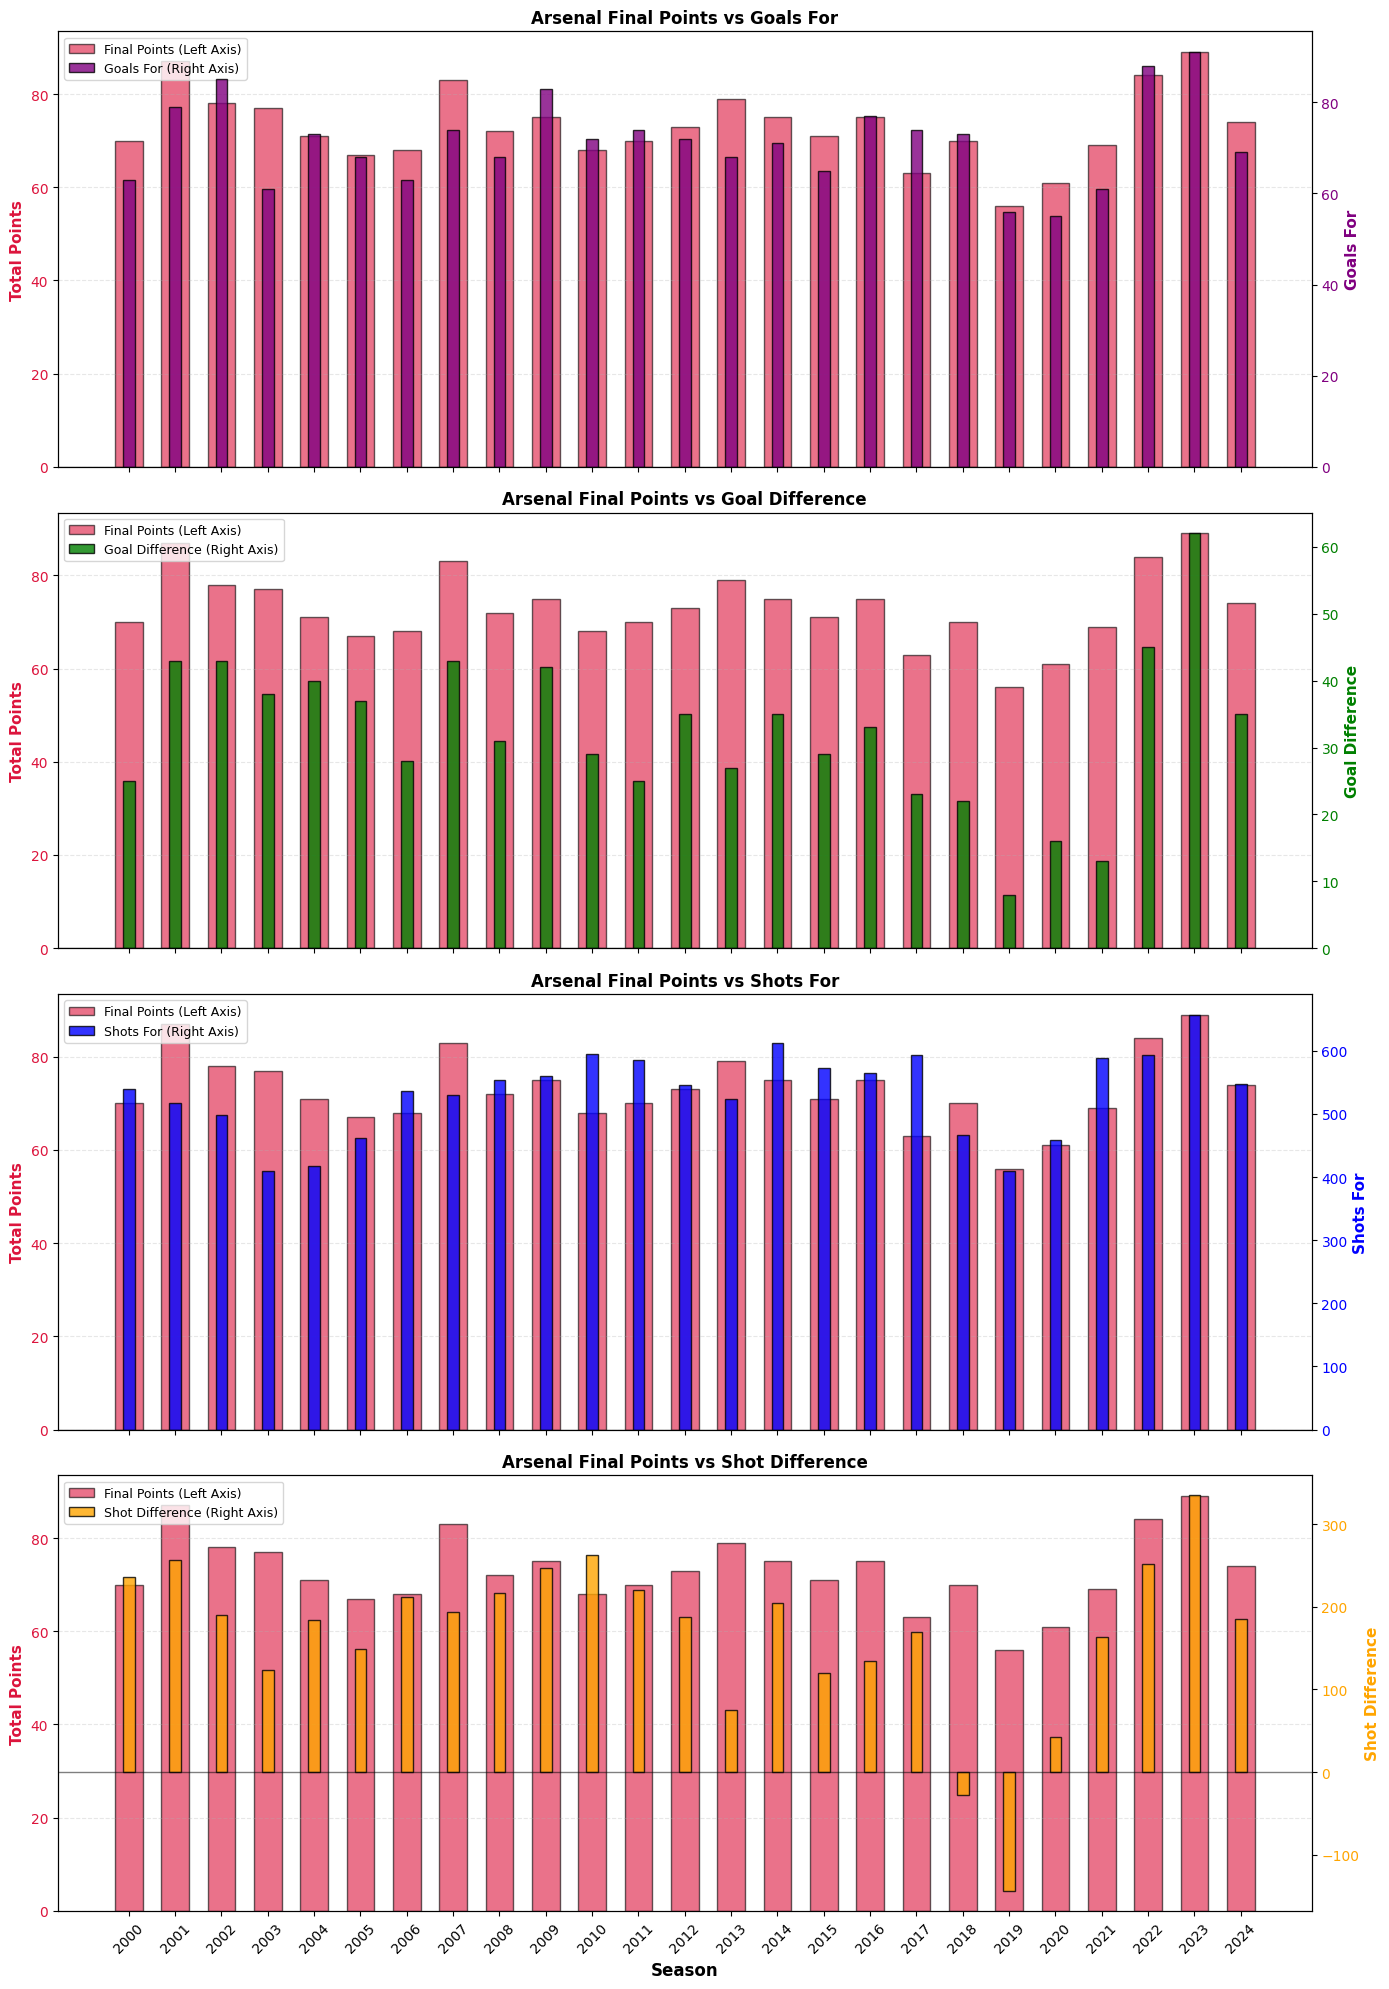

In [15]:
# Define each metric to plot alongside points
metrics = [
    ("cumulative_goals_for", "Goals For", "purple"),
    ("cumulative_goal_difference", "Goal Difference", "green"),
    ("cumulative_shots_for", "Shots For", "blue"),
    ("cumulative_shot_difference", "Shot Difference", "orange"),
]

fig, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=True)

for ax1, (col, label, colour) in zip(axes, metrics):
    # --- Left Axis: Final Points ---
    bars_points = ax1.bar(
        seasons,
        final_points,
        color="crimson",
        alpha=0.6,
        width=0.6,
        edgecolor="black",
        label="Final Points (Left Axis)",
    )
    ax1.set_ylabel("Total Points", color="crimson", fontsize=11, fontweight="bold")
    ax1.tick_params(axis="y", labelcolor="crimson")
    ax1.grid(axis="y", linestyle="--", alpha=0.3)

    # --- Right Axis: Current metric ---
    ax2 = ax1.twinx()
    bars_metric = ax2.bar(
        seasons,
        season_summary[col],
        color=colour,
        alpha=0.8,
        width=0.25,
        edgecolor="black",
        label=f"{label} (Right Axis)",
    )
    ax2.set_ylabel(label, color=colour, fontsize=11, fontweight="bold")
    ax2.tick_params(axis="y", labelcolor=colour)
    ax2.axhline(0, color="black", linestyle="-", linewidth=1, alpha=0.5)

    # --- Legend and title per subplot ---
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left", fontsize=9)
    ax1.set_title(f"Arsenal Final Points vs {label}", fontsize=12, fontweight="bold")

# Only the bottom subplot needs x tick labels (shared x-axis)
axes[-1].set_xlabel("Season", fontsize=12, fontweight="bold")
axes[-1].set_xticks(seasons)
axes[-1].set_xticklabels(seasons, rotation=45)

plt.tight_layout()
plt.show()

The plots suggest that Arsenal's stronger seasons tend to coincide with higher values of these performance measures. However, visual inspection alone does not quantify the strength of these relationships. I will therefore calculate correlation coefficients in the statistical analysis section to determine how strongly each measure is associated with final points.

## 3.5 Shots and Goals

The previous analysis considered performance over an entire season. I will now return to the individual-match level and investigate whether Arsenal's shot volume is associated with the number of goals it scores.

The question is whether taking more shots tends to result in more goals, and if so, how strong this relationship is.

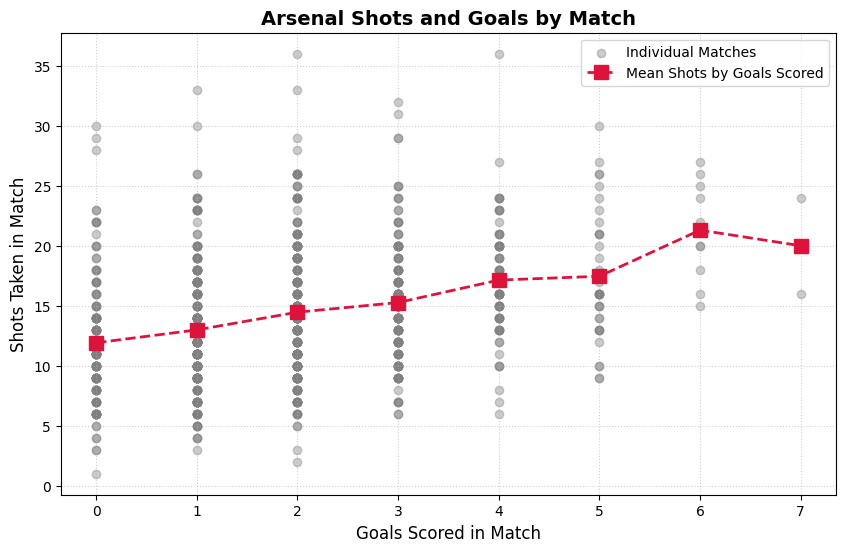

In [16]:
# total shots in a match
ArsenalData['shots'] = np.where(
    ArsenalData['HomeTeam'] == 'Arsenal',
    ArsenalData['HomeShots'],
    ArsenalData['AwayShots']
) 

# total goals in a match
ArsenalData['goals'] = np.where(
    ArsenalData['HomeTeam'] == 'Arsenal',
    ArsenalData['FTHome'],
    ArsenalData['FTAway']
) 

# mean
mean_shots_per_goal = ArsenalData.groupby("goals")["shots"].mean()

plt.figure(figsize=(10, 6))

plt.scatter(
    ArsenalData["goals"],
    ArsenalData["shots"],
    alpha=0.4,
    color="gray",
    label="Individual Matches",
)

plt.plot(
    mean_shots_per_goal.index,
    mean_shots_per_goal.values,
    color="crimson",
    marker="s",
    markersize=10,
    linestyle="--",
    linewidth=2,
    label="Mean Shots by Goals Scored",
)

plt.title("Arsenal Shots and Goals by Match", fontsize=14, fontweight="bold")
plt.xlabel("Goals Scored in Match", fontsize=12)
plt.ylabel("Shots Taken in Match", fontsize=12)
plt.xticks(
    np.arange(0, ArsenalData["goals"].max() + 1, 1)
)  # Force integer steps on X-axis
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

The strength of this relationship will be quantified using correlation coefficients in the statistical analysis section.

## 3.6 Shot Dominance and Match Outcomes

The previous analysis considered whether Arsenal's own shot volume is associated with the number of goals it scores. I will now consider whether **shot dominance** is associated with match outcomes.

Shot dominance is measured as the difference between the number of shots taken by the home team and the number taken by the away team. The matches are grouped into ranges of shot difference, allowing the distribution of home wins, draws and away wins to be compared across different levels of shot dominance.

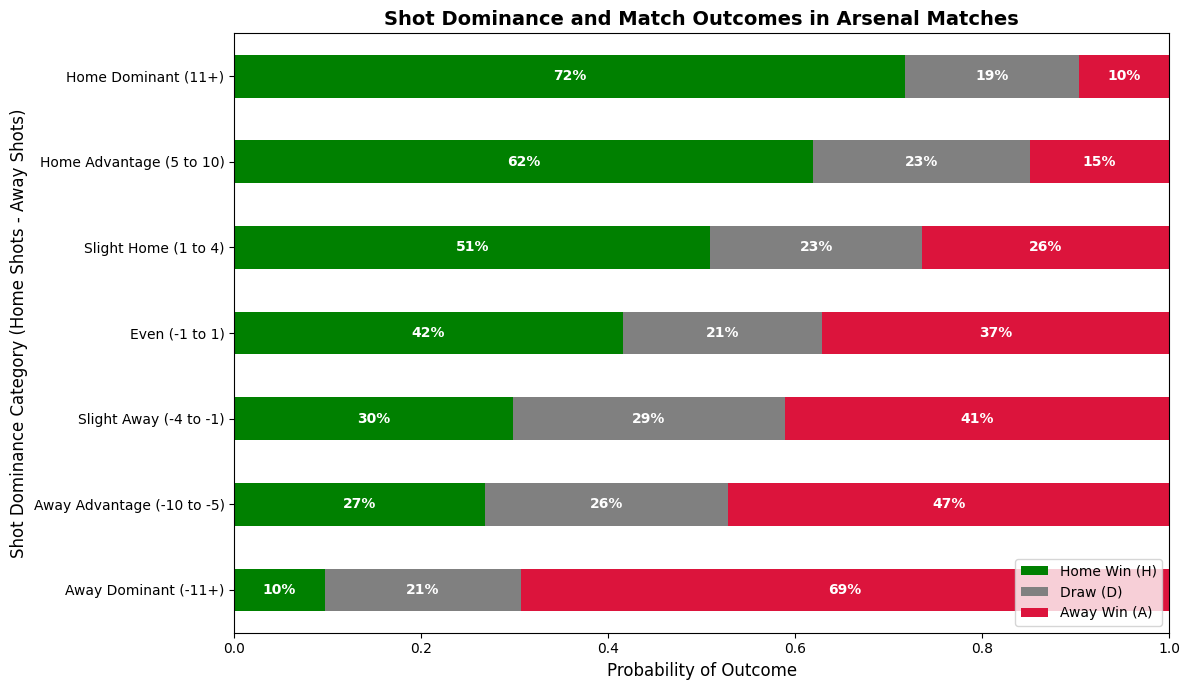

In [17]:
# Calculate the Shot Difference for the Home Team in every match
# Positive numbers = Home team took more shots; Negative = Away team took more
ArsenalData["Home_Shot_Diff"] = (
    ArsenalData["HomeShots"] - ArsenalData["AwayShots"]
)

# Define your shot dominance categories (bins) and clear labels
# You can adjust these thresholds based on your dataset's distribution
bins = [-np.inf, -10, -5, -1, 1, 5, 10, np.inf]
labels = [
    "Away Dominant (-11+)",
    "Away Advantage (-10 to -5)",
    "Slight Away (-4 to -1)",
    "Even (-1 to 1)",
    "Slight Home (1 to 4)",
    "Home Advantage (5 to 10)",
    "Home Dominant (11+)",
]

# Assign each match to a dominance category using pd.cut
ArsenalData["Dominance_Category"] = pd.cut(
    ArsenalData["Home_Shot_Diff"], bins=bins, labels=labels
)

# Calculate probabilities (percentages) of results within each category
# This counts how often H, D, or A occurs for each shot tier
prob_df = (
    ArsenalData.groupby("Dominance_Category", observed=False)["FTResult"]
    .value_counts(normalize=True)  # Converts raw counts to percentages (0.0 to 1.0)
    .unstack()  # Moves H, D, A from rows into clean columns
    .fillna(0)  # Replaces any empty results with 0%
)

# Reorder columns logically for standard sports reading: Home Win, Draw, Away Win
prob_df = prob_df[["H", "D", "A"]]

# Plot the stacked horizontal bar chart
ax = prob_df.plot(
    kind="barh", figsize=(12, 7), stacked=True, color=["green", "gray", "crimson"]
)

# Add custom labels and styling
plt.title(
    "Shot Dominance and Match Outcomes in Arsenal Matches",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Probability of Outcome", fontsize=12)
plt.ylabel("Shot Dominance Category (Home Shots - Away Shots)", fontsize=12)
plt.xlim(0, 1.0)  # Forces the X-axis to stay bounded between 0% and 100%

# Add clean percentage labels inside the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if width > 0.05:  # Only display labels if the bar segment is wide enough to read
        x, y = p.get_xy()
        ax.text(
            x + width / 2,
            y + height / 2,
            f"{width*100:.0f}%",
            horizontalalignment="center",
            verticalalignment="center",
            color="white",
            fontweight="bold",
        )

plt.legend(["Home Win (H)", "Draw (D)", "Away Win (A)"], loc="lower right")
plt.tight_layout()
plt.show()

# 4. Comparing Premier League Clubs

Having explored Arsenal's performance in detail, I will now widen the analysis to compare clubs against one another. This section considers Elo ratings as a measure of relative team strength over time, before examining home advantage — first among the traditional "top six" clubs, and then across the Premier League as a whole.

## 4.1 Elo Rating Progression

Elo ratings provide a continuous measure of team strength that updates after every match, making them useful for comparing clubs over time in a way that raw league position cannot. I will plot the Elo progression of the top six clubs across the full 2000–2025 period, using a match-by-match index rather than calendar date so that each team's ratings are shown as an uninterrupted sequence, unaffected by summer breaks between seasons.

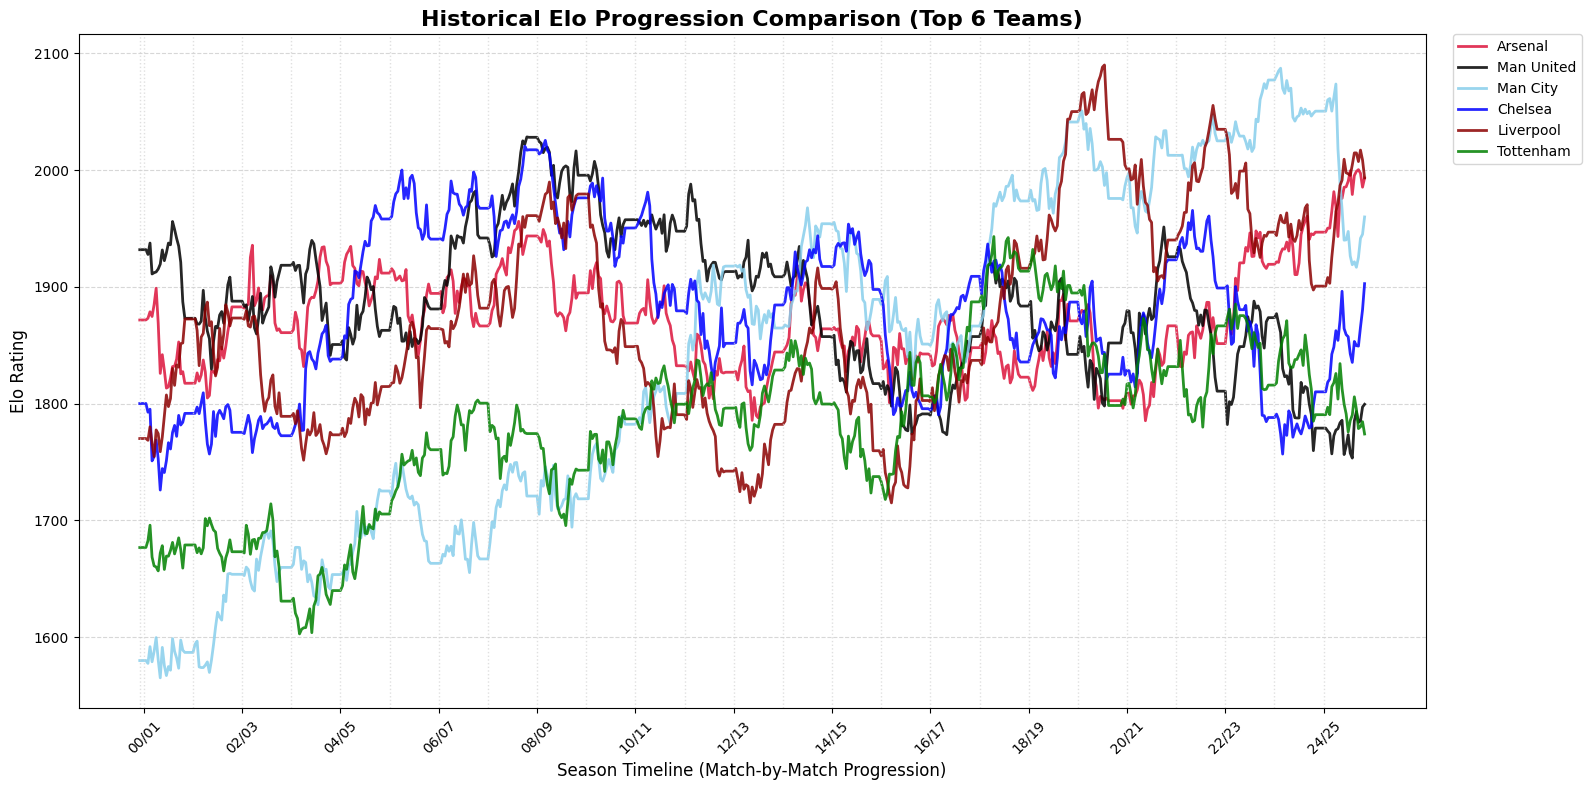

In [18]:
EloRatings["date"] = pd.to_datetime(EloRatings["date"])
EloRatings = EloRatings.sort_values("date").reset_index(drop=True)

top_6 = [
    "Arsenal",
    "Man United",
    "Man City",
    "Chelsea",
    "Liverpool",
    "Tottenham",
]
team_colors = {
    "Arsenal": "crimson",
    "Man United": "black",
    "Man City": "skyblue",
    "Chelsea": "blue",
    "Liverpool": "darkred",
    "Tottenham": "green",
}

df_top6 = EloRatings[EloRatings["club"].isin(top_6)].copy()
df_top6 = df_top6.sort_values(["club", "date"]).reset_index(drop=True)
df_top6["Match_Index"] = df_top6.groupby("club").cumcount()

plt.figure(figsize=(16, 8))

for team in top_6:
    team_df = df_top6[df_top6["club"] == team]
    plt.plot(
        team_df["Match_Index"],
        team_df["elo"],
        label=team,
        color=team_colors[team],
        linewidth=2,
        alpha=0.85,
    )

def get_football_season(date_val):
    year = date_val.year
    if date_val.month >= 8:
        return f"{str(year)[2:]}/{str(year+1)[2:]}"
    else:
        return f"{str(year-1)[2:]}/{str(year)[2:]}"

reference_team = df_top6[df_top6["club"] == "Arsenal"].copy()
reference_team["Football_Season"] = reference_team["date"].apply(get_football_season)
season_boundaries = reference_team.groupby("Football_Season")["Match_Index"].min()

for idx in season_boundaries.values:
    plt.axvline(x=idx, color="lightgray", linestyle=":", alpha=0.7, linewidth=1)

plt.xticks(
    ticks=season_boundaries.values[::2],
    labels=season_boundaries.index[::2],
    rotation=45,
)

plt.title("Historical Elo Progression Comparison (Top 6 Teams)", fontsize=16, fontweight="bold")
plt.xlabel("Season Timeline (Match-by-Match Progression)", fontsize=12)
plt.ylabel("Elo Rating", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

## 4.2 Home Advantage Among the Top Six

Home advantage is a well-documented phenomenon in football, generally attributed to factors such as crowd support, travel fatigue for the away side, and pitch familiarity. I will first examine this effect among the top six clubs by comparing their win percentage and average goals scored at home versus away.

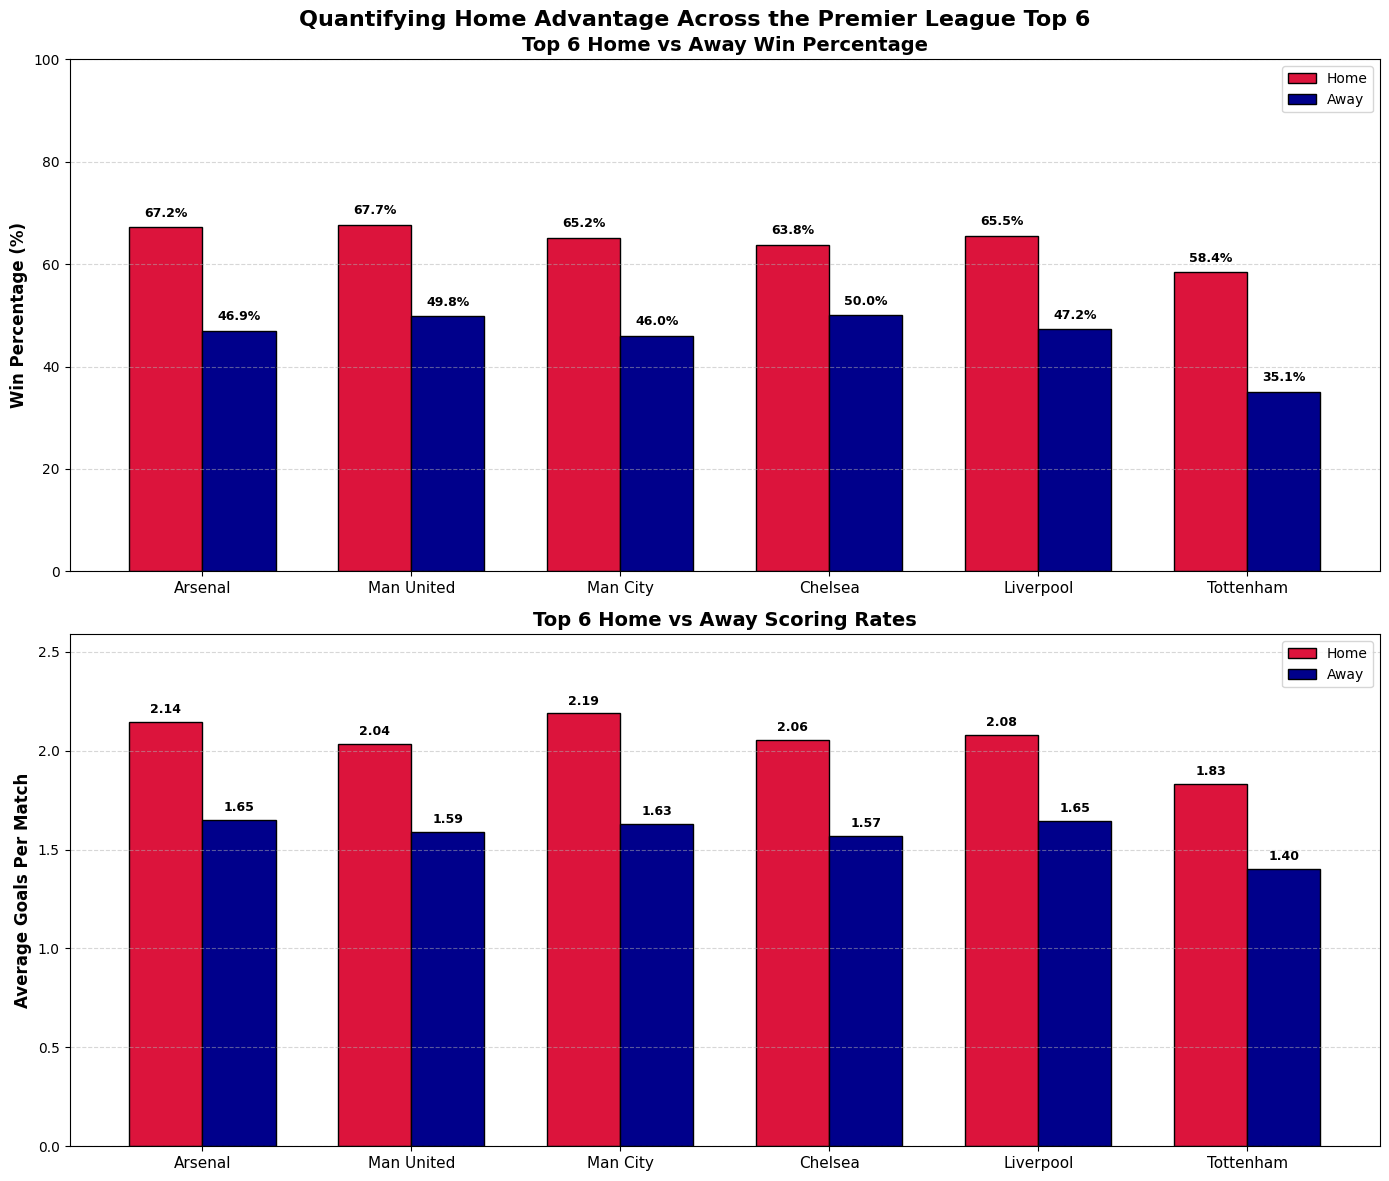

In [19]:
top6_summary = []

for team in top_6:
    home_games = PremData[PremData["HomeTeam"] == team]
    away_games = PremData[PremData["AwayTeam"] == team]

    total_home = len(home_games)
    total_away = len(away_games)
    home_win_pct = (home_games["FTResult"].eq("H").sum() / total_home * 100) if total_home else 0
    away_win_pct = (away_games["FTResult"].eq("A").sum() / total_away * 100) if total_away else 0

    top6_summary.append({
        "Team": team,
        "Home Win %": home_win_pct,
        "Away Win %": away_win_pct,
        "Home Goals/Game": home_games["FTHome"].mean(),
        "Away Goals/Game": away_games["FTAway"].mean(),
    })

summary_df = pd.DataFrame(top6_summary)

x = np.arange(len(top_6))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

bars_home_win = ax1.bar(x - width/2, summary_df["Home Win %"], width, label="Home", color="crimson", edgecolor="black")
bars_away_win = ax1.bar(x + width/2, summary_df["Away Win %"], width, label="Away", color="darkblue", edgecolor="black")
ax1.set_ylabel("Win Percentage (%)", fontsize=12, fontweight="bold")
ax1.set_title("Top 6 Home vs Away Win Percentage", fontsize=14, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(top_6, fontsize=11)
ax1.set_ylim(0, 100)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.legend(loc="upper right")

for bar in list(bars_home_win) + list(bars_away_win):
    yval = bar.get_height()
    if yval > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%",
                  ha="center", va="bottom", fontsize=9, fontweight="bold")

bars_home_goals = ax2.bar(x - width/2, summary_df["Home Goals/Game"], width, label="Home", color="crimson", edgecolor="black")
bars_away_goals = ax2.bar(x + width/2, summary_df["Away Goals/Game"], width, label="Away", color="darkblue", edgecolor="black")
ax2.set_ylabel("Average Goals Per Match", fontsize=12, fontweight="bold")
ax2.set_title("Top 6 Home vs Away Scoring Rates", fontsize=14, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(top_6, fontsize=11)
ax2.set_ylim(0, max(summary_df["Home Goals/Game"].max(), summary_df["Away Goals/Game"].max()) + 0.4)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.legend(loc="upper right")

for bar in list(bars_home_goals) + list(bars_away_goals):
    yval = bar.get_height()
    if yval > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.03, f"{yval:.2f}",
                  ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Quantifying Home Advantage Across the Premier League Top 6", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

## 4.3 Home Advantage Across the Premier League

To establish whether home advantage is a league-wide effect rather than one specific to the top six, I will extend the comparison to every club with a reasonable number of matches in the dataset (clubs with fewer than 10 home or away matches are excluded, as such small samples can produce extreme or misleading percentages). Each club's home advantage is measured as the percentage-point difference between its home win rate and away win rate; a value of zero indicates a club with identical home and away win rates, rather than missing or undetected data. Finally, I will look at the distribution of match results across the league as a whole, as a baseline reference point for the analysis in the following section.

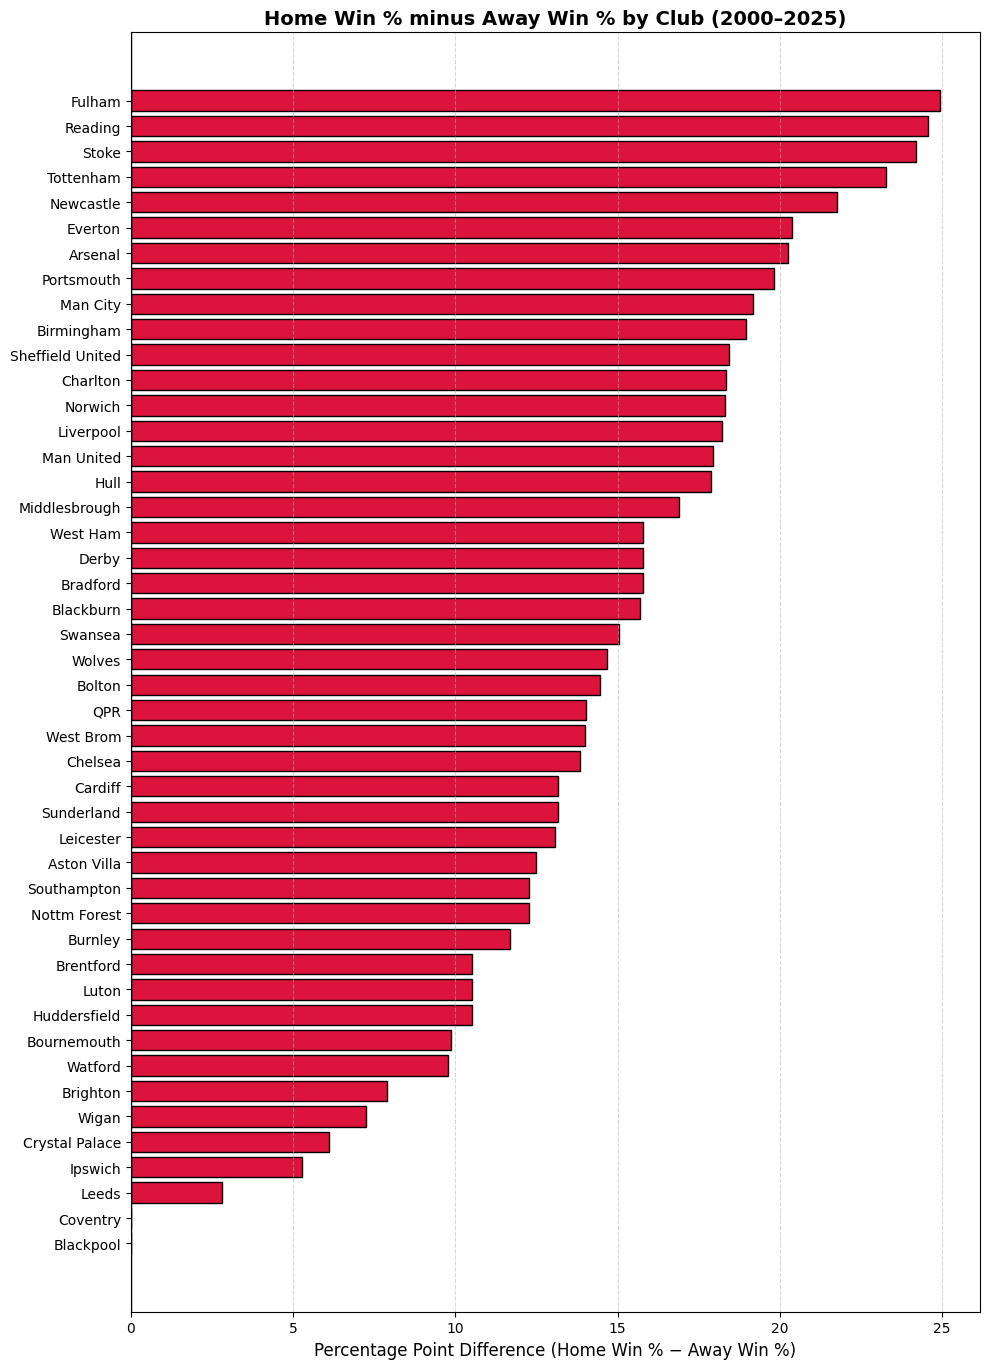

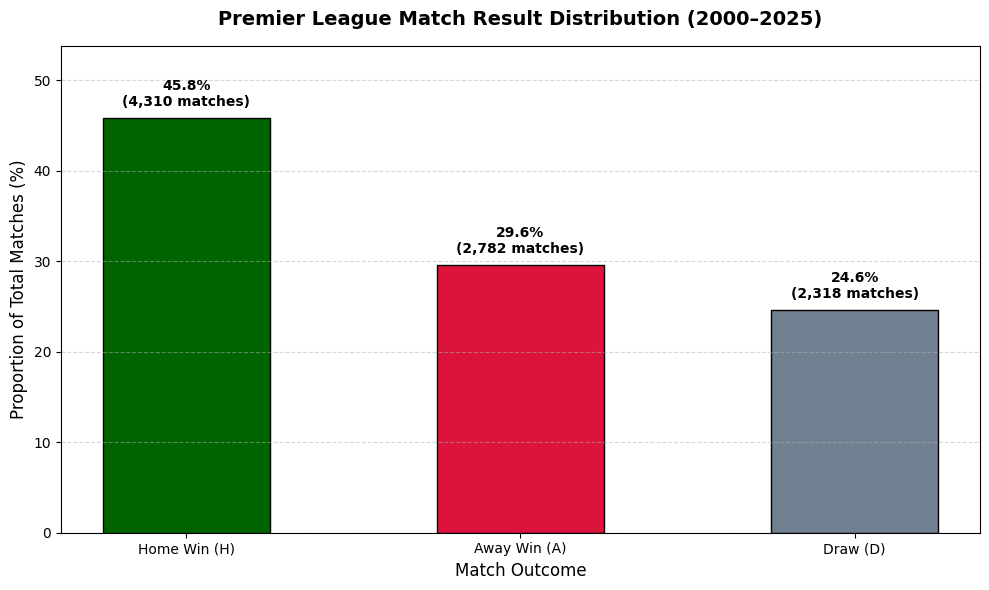

In [20]:
all_teams = sorted(set(PremData["HomeTeam"]) | set(PremData["AwayTeam"]))
league_summary = []

for team in all_teams:
    home_games = PremData[PremData["HomeTeam"] == team]
    away_games = PremData[PremData["AwayTeam"] == team]
    total_home = len(home_games)
    total_away = len(away_games)

    # skip clubs with very few matches in one venue (avoids noisy %s from tiny samples)
    if total_home < 10 or total_away < 10:
        continue

    home_win_pct = home_games["FTResult"].eq("H").sum() / total_home * 100
    away_win_pct = away_games["FTResult"].eq("A").sum() / total_away * 100

    league_summary.append({
        "Team": team,
        "Home Win %": home_win_pct,
        "Away Win %": away_win_pct,
        "Home Advantage (pp)": home_win_pct - away_win_pct,
    })

league_df = pd.DataFrame(league_summary).sort_values("Home Advantage (pp)", ascending=True)

plt.figure(figsize=(10, max(6, len(league_df) * 0.3)))
plt.barh(league_df["Team"], league_df["Home Advantage (pp)"], color="crimson", edgecolor="black")
plt.axvline(0, color="black", linewidth=1)
plt.title("Home Win % minus Away Win % by Club (2000–2025)", fontsize=14, fontweight="bold")
plt.xlabel("Percentage Point Difference (Home Win % − Away Win %)", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# League-wide baseline result split (for reference)
result_counts = PremData["FTResult"].value_counts()
result_proportions = PremData["FTResult"].value_counts(normalize=True) * 100

ordered_labels = ["Home Win (H)", "Away Win (A)", "Draw (D)"]
counts = [result_counts.get(k, 0) for k in ["H", "A", "D"]]
proportions = [result_proportions.get(k, 0) for k in ["H", "A", "D"]]

plt.figure(figsize=(10, 6))
colors = ["darkgreen", "crimson", "slategrey"]
bars = plt.bar(ordered_labels, proportions, color=colors, width=0.5, edgecolor="black")

plt.title("Premier League Match Result Distribution (2000–2025)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Match Outcome", fontsize=12)
plt.ylabel("Proportion of Total Matches (%)", fontsize=12)
plt.ylim(0, max(proportions) + 8)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar, count, prop in zip(bars, counts, proportions):
    plt.text(bar.get_x() + bar.get_width()/2, prop + 1, f"{prop:.1f}%\n({count:,} matches)",
              ha="center", va="bottom", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

Taken together, these results suggest that home advantage is not confined to the league's strongest clubs but is a broader pattern across the Premier League, even if its size varies from club to club. The Elo comparison also highlights how the relative strength of the top six has shifted over the 25-season period, rather than remaining static. Whether the home advantage observed here is statistically significant, and how strongly the performance measures explored in this and the previous section relate to points, will be examined formally in the next section.

# 5. Statistical Analysis

The previous sections identified several visual patterns: stronger Arsenal seasons appeared 
to coincide with higher goals, goal difference, shots and shot difference; shot volume 
appeared loosely related to goals scored; and home advantage appeared to hold across the 
league. This section quantifies these relationships using correlation coefficients and a 
formal statistical test.

## 5.1 Correlation Between Performance Metrics and Points

I will calculate the Pearson correlation coefficient between Arsenal's final points tally 
each season and each of the four performance measures considered in section 3.4: goals, 
goal difference, shots, and shot difference.

In [21]:
corr_targets = {
    "Goals For": "cumulative_goals_for",
    "Goal Difference": "cumulative_goal_difference",
    "Shots For": "cumulative_shots_for",
    "Shot Difference": "cumulative_shot_difference",
}

correlations = {
    label: season_summary["CumulativePoints"].corr(season_summary[col])
    for label, col in corr_targets.items()
}

for label, r in correlations.items():
    print(f"• {label}: r = {r:.3f}")

• Goals For: r = 0.716
• Goal Difference: r = 0.839
• Shots For: r = 0.361
• Shot Difference: r = 0.600


As expected, goal difference shows the strongest relationship with final points (r = 0.839), followed by goals scored (r = 0.716). Shot difference shows a moderate relationship (r = 0.600), while shot volume alone is only weakly correlated with points (r = 0.361). This supports the idea that outcome-based measures (goals, goal difference) are more closely tied to points than pre-outcome measures of attacking activity (shots, shot difference) — taking shots matters, but converting them matters more.

## 5.2 Correlation Between Shots and Goals

Section 3.5 examined whether Arsenal's shot volume was associated with the number of goals scored in a match. I will now quantify this relationship separately for home and away matches, since home advantage may affect how efficiently shots are converted into goals.

In [22]:
arsenal_home = ArsenalData[ArsenalData["HomeTeam"] == "Arsenal"].copy()
home_corr = arsenal_home["HomeShots"].corr(arsenal_home["FTHome"])

arsenal_away = ArsenalData[ArsenalData["AwayTeam"] == "Arsenal"].copy()
away_corr = arsenal_away["AwayShots"].corr(arsenal_away["FTAway"])

print("Arsenal Shot-to-Goal Correlation Coefficients:")
print(f"• Home Matches (HomeShots vs FTHome): {home_corr:.4f}")
print(f"• Away Matches (AwayShots vs FTAway): {away_corr:.4f}")

Arsenal Shot-to-Goal Correlation Coefficients:
• Home Matches (HomeShots vs FTHome): 0.2234
• Away Matches (AwayShots vs FTAway): 0.3670


Both coefficients are positive but modest, suggesting that while taking more shots is associated with scoring more goals, shot volume alone explains only part of the variation in goals scored — shot quality and conversion efficiency are also likely to play a role. The away correlation is slightly stronger than the home correlation, which is worth noting but not over-interpreted given the relatively small number of matches involved.

## 5.3 Statistical Significance

Section 4.2 showed that the top six clubs won a higher percentage of their home matches than their away matches, and section 4.3 extended this pattern across the league. To test whether home advantage is statistically significant rather than attributable to chance, I will apply a chi-square test of independence to the league-wide match result distribution, comparing the observed frequency of home wins, draws and away wins against the frequency expected under a null hypothesis of no home advantage (i.e. home and away wins equally likely).

In [23]:
from scipy.stats import chisquare

observed = PremData["FTResult"].value_counts()[["H", "D", "A"]]

# Null hypothesis: home wins and away wins are equally likely; draws unconstrained
# Expected: split H/A evenly based on their combined total, keep observed draw count
home_away_total = observed["H"] + observed["A"]
expected = pd.Series({
    "H": home_away_total / 2,
    "D": observed["D"],
    "A": home_away_total / 2,
})

chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"p-value: {p_value:.6f}")

Chi-square statistic: 329.21
p-value: 0.000000


With a chi-square statistic of 329.21 and a p-value far below the conventional 0.05 threshold, the null hypothesis of no home advantage can be firmly rejected. This confirms that the pattern observed visually in section 4 — home teams winning more often than away teams — is highly unlikely to be due to chance, and provides statistical support for the existence of home advantage across the Premier League over this period.

Together, these results confirm two of the patterns identified visually in earlier sections: performance measures — particularly goal difference — are meaningfully associated with a team's final points tally, and home advantage is a statistically robust effect across the league. The next section builds on this by using pre-match information to predict match outcomes directly.

# 6. Predicting Match Outcomes

Having explored Arsenal's performance and quantified relationships between performance measures and results across the league, I will now investigate whether match outcomes can be predicted using information available before kick-off. This involves engineering features from historical form and team strength, and comparing the predictive performance of several classification models against a simple baseline.

## 6.1 Defining the Prediction Problem

The prediction task is framed as a binary classification problem: predicting whether the home team wins a given match (1) or not (0), with draws and away wins grouped together as the negative class. This framing was chosen over a three-way classification (home win, draw, away win) to keep the initial modelling straightforward, since draws are historically the hardest outcome to predict and would be expected to reduce accuracy across all classes.

To ensure predictions reflect a realistic forecasting scenario, matches are kept in strict chronological order throughout, and the train/test split is performed by date rather than randomly — the model is trained only on earlier matches and tested on later ones.

## 6.2 Feature Engineering

Three features are engineered for each match:

- **Elo differential** — the difference between the home and away team's Elo ratings before the match, capturing the underlying quality gap between the two sides.
- **Form points differential** — the difference between the home and away team's total points earned over their previous 5 matches.
- **Form goal difference differential** — the difference between the home and away team's goal difference over their previous 5 matches.

Since `HomeShots`, `HomeElo` and similar columns describe only one side of the match, the data is first reshaped into a team-by-team "timeline" format, where each match contributes one row for the home team and one row for the away team. This makes it possible to calculate each team's rolling form independently of whether they were playing at home or away in a given match, before the home/away perspective is reconstructed for modelling.

In [24]:
# 1. Ensure absolute chronological order across the matches dataset
df = PremData.sort_values("MatchDate").reset_index(drop=True)

# 2. Map match outcomes to points earned by the home and away side
df["home_pts_earned"] = np.select(
    [df["FTResult"] == "H", df["FTResult"] == "D"], [3, 1], default=0
)
df["away_pts_earned"] = np.select(
    [df["FTResult"] == "A", df["FTResult"] == "D"], [3, 1], default=0
)

# 3. Reshape into a team-by-team timeline to calculate rolling form
timeline = []
for idx, row in df.iterrows():
    timeline.append({
        "match_idx": idx,
        "team": row["HomeTeam"],
        "is_home": 1,
        "goals_for": row["FTHome"],
        "goals_against": row["FTAway"],
        "pts": row["home_pts_earned"],
    })
    timeline.append({
        "match_idx": idx,
        "team": row["AwayTeam"],
        "is_home": 0,
        "goals_for": row["FTAway"],
        "goals_against": row["FTHome"],
        "pts": row["away_pts_earned"],
    })

timeline_df = pd.DataFrame(timeline).sort_values("match_idx")
timeline_df["gd_per_match"] = timeline_df["goals_for"] - timeline_df["goals_against"]

## 6.3 Preventing Data Leakage

A key risk in this kind of feature engineering is data leakage: including information in a match's features that would not actually have been available before that match was played. For example, calculating a team's rolling form using their most recent 5 matches, *including the current match*, would leak the outcome being predicted into the feature itself.

To prevent this, each team's rolling form statistics are shifted forward by one match after being calculated, so that the features attached to a given match reflect only the team's form going into that match, not including its result. The first match of each team's history has no prior form and is filled with 0 rather than left missing.

In [25]:
# Rolling 5-game form, shifted by 1 so the current match's result isn't included
timeline_df["form_pts_5"] = (
    timeline_df.groupby("team")["pts"]
    .transform(lambda x: x.rolling(5, min_periods=1).sum())
    .groupby(timeline_df["team"])
    .shift(1)
)

timeline_df["form_gd_5"] = (
    timeline_df.groupby("team")["gd_per_match"]
    .transform(lambda x: x.rolling(5, min_periods=1).sum())
    .groupby(timeline_df["team"])
    .shift(1)
)

timeline_df.fillna(0, inplace=True)

# Merge the shifted form features back into the match-level dataframe
home_features = timeline_df[timeline_df["is_home"] == 1][
    ["match_idx", "form_pts_5", "form_gd_5"]
].rename(columns={"form_pts_5": "home_form_pts", "form_gd_5": "home_form_gd"})

away_features = timeline_df[timeline_df["is_home"] == 0][
    ["match_idx", "form_pts_5", "form_gd_5"]
].rename(columns={"form_pts_5": "away_form_pts", "form_gd_5": "away_form_gd"})

df = df.merge(home_features, left_index=True, right_on="match_idx").drop(columns=["match_idx"])
df = df.merge(away_features, left_index=True, right_on="match_idx").drop(columns=["match_idx"])

# Net differential features
df["diff_form_pts"] = df["home_form_pts"] - df["away_form_pts"]
df["diff_form_gd"] = df["home_form_gd"] - df["away_form_gd"]
df["elo_diff"] = df["HomeElo"] - df["AwayElo"]

print(df[["HomeTeam", "AwayTeam", "elo_diff", "diff_form_pts"]].head())

    HomeTeam       AwayTeam  elo_diff  diff_form_pts
1   Charlton       Man City     28.78            0.0
5    Chelsea       West Ham    118.81            0.0
9   Coventry  Middlesbrough    -43.57            0.0
13     Derby    Southampton      6.06            0.0
17     Leeds        Everton     97.00            0.0


## 6.4 Baseline Prediction

Before evaluating any model, it is useful to establish a simple baseline for comparison. Since home teams win more often than they lose across the league (section 4.3), the baseline model always predicts a home win. Any model developed afterwards should outperform this baseline to be considered useful.

In [26]:
df["is_home_win_target"] = (df["FTResult"] == "H").astype(int)

features = ["elo_diff", "diff_form_pts", "diff_form_gd"]
X = df[features]
y = df["is_home_win_target"]

# Chronological train/test split — no shuffling, to simulate real forecasting conditions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_preds = np.ones(len(y_test))
baseline_accuracy = accuracy_score(y_test, baseline_preds)

print(f"Baseline Accuracy (Always Predict Home Win): {baseline_accuracy*100:.2f}%")

Baseline Accuracy (Always Predict Home Win): 45.38%


## 6.5 Logistic Regression

Logistic regression is fitted using the three engineered features, with feature scaling applied first, since the Elo differential operates on a much larger numerical scale than the form differentials, and logistic regression is sensitive to this kind of scale imbalance.

In [27]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

model_preds = log_reg.predict(X_test_scaled)
model_accuracy = accuracy_score(y_test, model_preds)

print(f"Logistic Regression Accuracy (Form + Elo Features): {model_accuracy*100:.2f}%")

print("\nLogistic Regression Feature Weights")
for feature, coef in zip(features, log_reg.coef_[0]):
    print(f"• {feature}: {coef:.4f}")

Logistic Regression Accuracy (Form + Elo Features): 63.55%

Logistic Regression Feature Weights
• elo_diff: 0.8051
• diff_form_pts: -0.0301
• diff_form_gd: 0.0151


## 6.6 Random Forest

As an alternative, non-linear approach, a random forest classifier is fitted on the same 
features. Tree-based models do not require feature scaling, so the unscaled versions of the 
features are used here. The maximum tree depth is limited to 4 to reduce the risk of 
overfitting, given the relatively noisy, low-signal nature of football match data.

In [28]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_preds)

print(f"Random Forest Classifier Accuracy: {rf_accuracy*100:.2f}%")

Random Forest Classifier Accuracy: 64.72%


## 6.7 Feature Importance

The random forest's built-in feature importance scores provide a way to assess which of the three engineered features contributed most to its predictions.

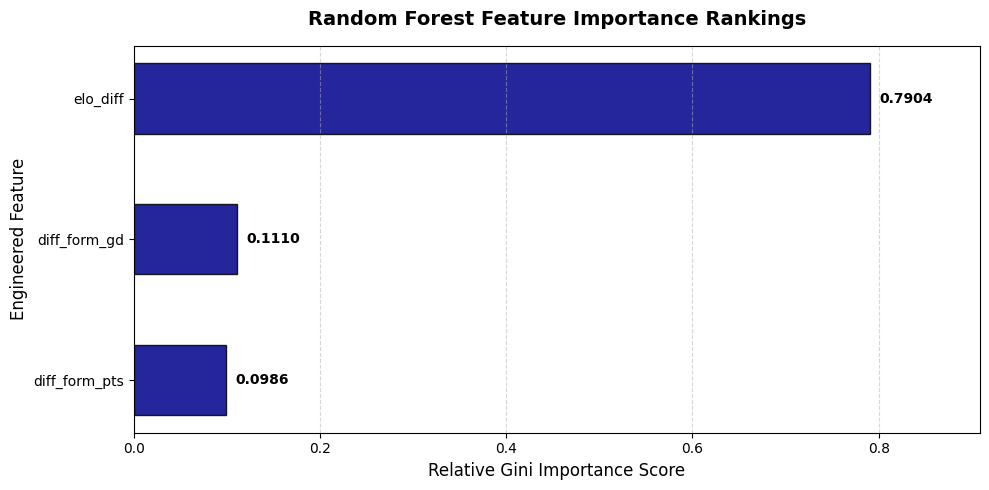

In [29]:
rf_importances = rf_model.feature_importances_
importance_df = pd.DataFrame({"Feature": features, "Importance": rf_importances})
importance_df = importance_df.sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color="darkblue",
    edgecolor="black",
    height=0.5,
    alpha=0.85,
)

plt.title("Random Forest Feature Importance Rankings", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Relative Gini Importance Score", fontsize=12)
plt.ylabel("Engineered Feature", fontsize=12)
plt.xlim(0, max(importance_df["Importance"]) * 1.15)
plt.grid(axis="x", linestyle="--", alpha=0.5)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{width:.4f}",
              ha="left", va="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

## 6.8 Model Comparison

The table below summarises the accuracy of each approach.

| Model | Accuracy |
|---|---|
| Baseline (always predict home win) | 45.38% |
| Logistic Regression | 63.55% |
| Random Forest | 64.72% |

Both models comfortably outperform the naive baseline, confirming that pre-match information — particularly Elo rating differential, which dominates the logistic regression coefficients and random forest feature importances — carries meaningful predictive signal. The random forest offers a small further improvement over logistic regression, suggesting a modest non-linear relationship between the features and match outcome, though the gap between the two models is relatively small compared to the gap between either model and the baseline.

# 7. Discussion

This notebook set out to explore patterns in Premier League match data and to investigate whether pre-match information could be used to predict outcomes. Several consistent findings emerged across the exploratory, statistical and modelling stages.

At the club level, Arsenal's season-by-season performance showed that goal difference was the strongest single predictor of final points (r = 0.839), considerably stronger than shot volume alone (r = 0.361). This suggests that while attacking activity contributes to a season's outcome, converting that activity into goals — and limiting goals conceded — matters more than generating shots for their own sake. The weaker, though still positive, correlation between shots and goals at the individual match level (r = 0.223 at home, r = 0.367 away) reinforces this: shot volume is only part of the picture, and factors such as shot quality and finishing were not captured directly in this analysis.

Home advantage was found to be a robust, league-wide effect rather than one confined to the strongest clubs. This was supported both descriptively, across all 46 clubs in the dataset, and formally, with a chi-square test rejecting the null hypothesis of no home advantage ($\chi^2$ = 329.21, p < 0.001). This is consistent with existing football analytics literature, which typically attributes home advantage to factors such as crowd support, travel and pitch familiarity — none of which were directly measurable in this dataset, but which the observed pattern is consistent with.

The predictive modelling stage showed that pre-match information carries genuine signal: both logistic regression (63.55%) and random forest (64.72%) comfortably outperformed the naive baseline of always predicting a home win (45.38%). Elo rating differential was by far the most influential feature in both models, considerably outweighing the two form-based features. This suggests that a team's underlying, longer-term strength is a stronger predictor of a given match's outcome than its very recent form, at least when form is measured only over the previous five matches.

**Limitations.** Several limitations should be acknowledged. The prediction task was framed as a binary classification (home win vs not), which simplifies the problem but discards information about draws specifically; a three-way classification would be a more complete, if more difficult, framing. The feature set used was also deliberately narrow — three engineered features — and did not include factors such as injuries, squad changes, managerial changes, or more detailed recent-form metrics (e.g. shots, expected goals). The random forest's modest improvement over logistic regression suggests some non-linearity in the relationship between features and outcome, but the small feature set limits how much a more complex model could realistically exploit. Finally, all modelling was restricted to the Premier League; the extent to which these patterns generalise to other leagues in the wider dataset was not tested.

# 8. Conclusion

This notebook analysed 25 seasons of Premier League match data, combining exploratory analysis, statistical testing and predictive modelling. Arsenal's performance over this period showed a clear relationship between goal-based performance measures and final league position, with goal difference the strongest indicator. Home advantage was confirmed as a statistically significant, league-wide phenomenon rather than one specific to elite clubs. Finally, simple pre-match features — particularly Elo rating differential — were shown to meaningfully improve prediction of match outcomes over a naive baseline, with both logistic regression and random forest models achieving accuracy in the low-to-mid 60% range.

Beyond the specific footballing conclusions, this notebook served as an opportunity to develop practical data analysis skills in Python: cleaning and validating real-world data, building appropriate visualisations, applying correlation and hypothesis testing, and constructing a leakage-free machine learning pipeline for a time-ordered prediction problem. Future work could extend this analysis by testing a wider range of features, framing the problem as three-way classification, or applying the same methodology to other leagues within the dataset.